# Dubai residential property prices · Exploratory data analysis

## 1. Project objective
Estimate Dubai residential property transaction prices from property characteristics, helping users establish a first-pass price expectation.

The **target**, `TRANS_VALUE`, is the recorded transaction amount in AED. This is **supervised learning** because historical records provide both property information and a known target. It is a **regression** problem because price is a continuous numeric quantity, rather than a class such as “expensive” or “affordable”.

**EDA (exploratory data analysis)** helps us understand the population, patterns and possible errors before modeling. This notebook inspects the raw export and creates an in-memory residential subset. It does not clean or overwrite any dataset, train a model, or change project rules.

## 2. Dataset overview
Source: [Dubai Land Department — official real estate data](https://dubailand.gov.ae/en/open-data/real-estate-data/). We inspect the supplied `transactions-2026-09-11.csv` export.

One row is a recorded transaction entry, **not necessarily one unique home or an individual whole-property sale**. A property may transact more than once, and some procedures may cover a development or another scope.

A **feature** is an input potentially useful for prediction, such as surface or location. The **target** is the value we want to predict. Being a column does not automatically make a field an appropriate feature: identifiers, administrative fields and target-derived values need review.

First check the size, column names and data types. A date stored as text needs parsing before chronological analysis. We display only five sample records and a compact schema table.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 10)
pd.set_option("display.max_rows", 25)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

DATA_PATH = ROOT / "data/raw/transactions-2026-09-11.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head(5))
display(df.dtypes.astype(str).rename("dtype").to_frame().rename_axis("column"))
dates = pd.to_datetime(df["INSTANCE_DATE"], errors="coerce")
print(f"Recorded date range: {dates.min()} to {dates.max()}")
print(f"Unparseable dates: {dates.isna().sum():,}")

Dataset: 113,866 rows × 22 columns


,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,...,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
0,102-1-2026,2026-01-01 16:21:33,Sales,Sell - Pre registration,Off-Plan,...,Expo 2020 Site,0,0,NaN,Hills View at Wasl Gate
1,102-10-2026,2026-01-02 03:15:44,Sales,Sell - Pre registration,Off-Plan,...,NaN,0,0,NaN,Expo Valley Views
2,102-100-2026,2026-01-02 11:46:55,Sales,Sell - Pre registration,Off-Plan,...,NaN,0,0,NaN,Altan
3,102-1000-2026,2026-01-06 07:20:07,Sales,Sell - Pre registration,Off-Plan,...,NaN,0,0,NaN,Palm Central Private Residences - Frond M
4,102-10000-2026,2026-01-28 18:41:20,Sales,Sell - Pre registration,Off-Plan,...,NaN,0,0,NaN,Villa dell Arte


,dtype
column,
TRANSACTION_NUMBER,str
INSTANCE_DATE,str
GROUP_EN,str
PROCEDURE_EN,str
IS_OFFPLAN_EN,str
IS_FREE_HOLD_EN,str
USAGE_EN,str
AREA_EN,str
PROP_TYPE_EN,str


Recorded date range: 2026-01-01 16:21:33 to 2026-09-11 11:44:44
Unparseable dates: 0


## 3. Data quality
**Missing data** means a value was not recorded or is unavailable; it does not always mean zero. We inspect the proportion missing before deciding whether to impute a field or exclude it later.

**Cardinality** is the number of distinct values. A constant column has no variation and cannot distinguish prices within the observed population. A mostly constant column may also add little information. Cardinality close to the row count can indicate an identifier: transaction numbers identify records rather than transferable property characteristics and can encourage memorization.

Exact duplicate rows and repeated transaction IDs are different issues. Repeated IDs deserve inspection before deciding which records, if any, are redundant. No duplicates are removed here.

,missing_rows,missing_pct,unique_nonmissing
MASTER_PROJECT_EN,113350,99.55,10
NEAREST_MALL_EN,64385,56.54,5
NEAREST_METRO_EN,62841,55.19,49
NEAREST_LANDMARK_EN,48489,42.58,13
PARKING,17093,15.01,11166
ROOMS_EN,9442,8.29,11
PROJECT_EN,7682,6.75,2846
PROP_SB_TYPE_EN,931,0.82,23
PROCEDURE_AREA,1,0.00,21464
PROP_TYPE_EN,0,0.00,3


Constant nonmissing columns: ['GROUP_EN', 'USAGE_EN', 'TOTAL_BUYER', 'TOTAL_SELLER']
Exact duplicate rows beyond first occurrence: 0
Repeated nonmissing IDs beyond first occurrence: 21


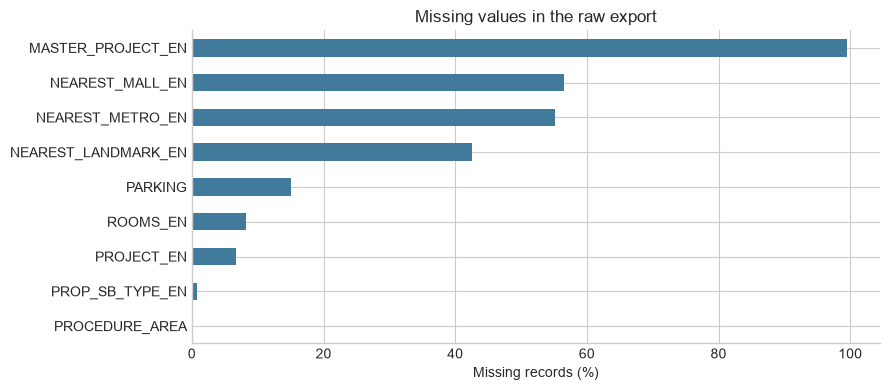

In [2]:
quality = pd.DataFrame({
    "missing_rows": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_nonmissing": df.nunique(dropna=True),
})
display(quality.sort_values("missing_pct", ascending=False))
print("Constant nonmissing columns:", quality.index[quality["unique_nonmissing"].eq(1)].tolist())
print(f"Exact duplicate rows beyond first occurrence: {df.duplicated().sum():,}")
ids = df["TRANSACTION_NUMBER"]
print(f"Repeated nonmissing IDs beyond first occurrence: {ids.dropna().duplicated().sum():,}")
missing = quality.loc[quality["missing_pct"].gt(0), "missing_pct"].sort_values()
if not missing.empty:
    ax = missing.plot.barh(color="#427a9b", figsize=(9, 4))
    ax.set(title="Missing values in the raw export", xlabel="Missing records (%)", ylabel="")
    plt.tight_layout()
    plt.show()

## 4. Categorical variables
**Categorical variables** describe groups rather than measured quantities. A **binary** category has two observed values, such as Ready and Off-Plan. Low-cardinality columns have relatively few categories; high-cardinality columns such as project names have many.

Most estimators need numeric representations of categories. Arbitrary integer labels can imply a false ordering; one-hot encoding is often suitable for small category sets. Rare or high-cardinality categories need a strategy learned from training data only.

The charts below cover the requested administrative and property categories in the **full raw export**. Counts show which groups dominate; rare groups may have too few examples for reliable modeling. Each chart shows at most 12 categories, with any remaining categories combined explicitly.

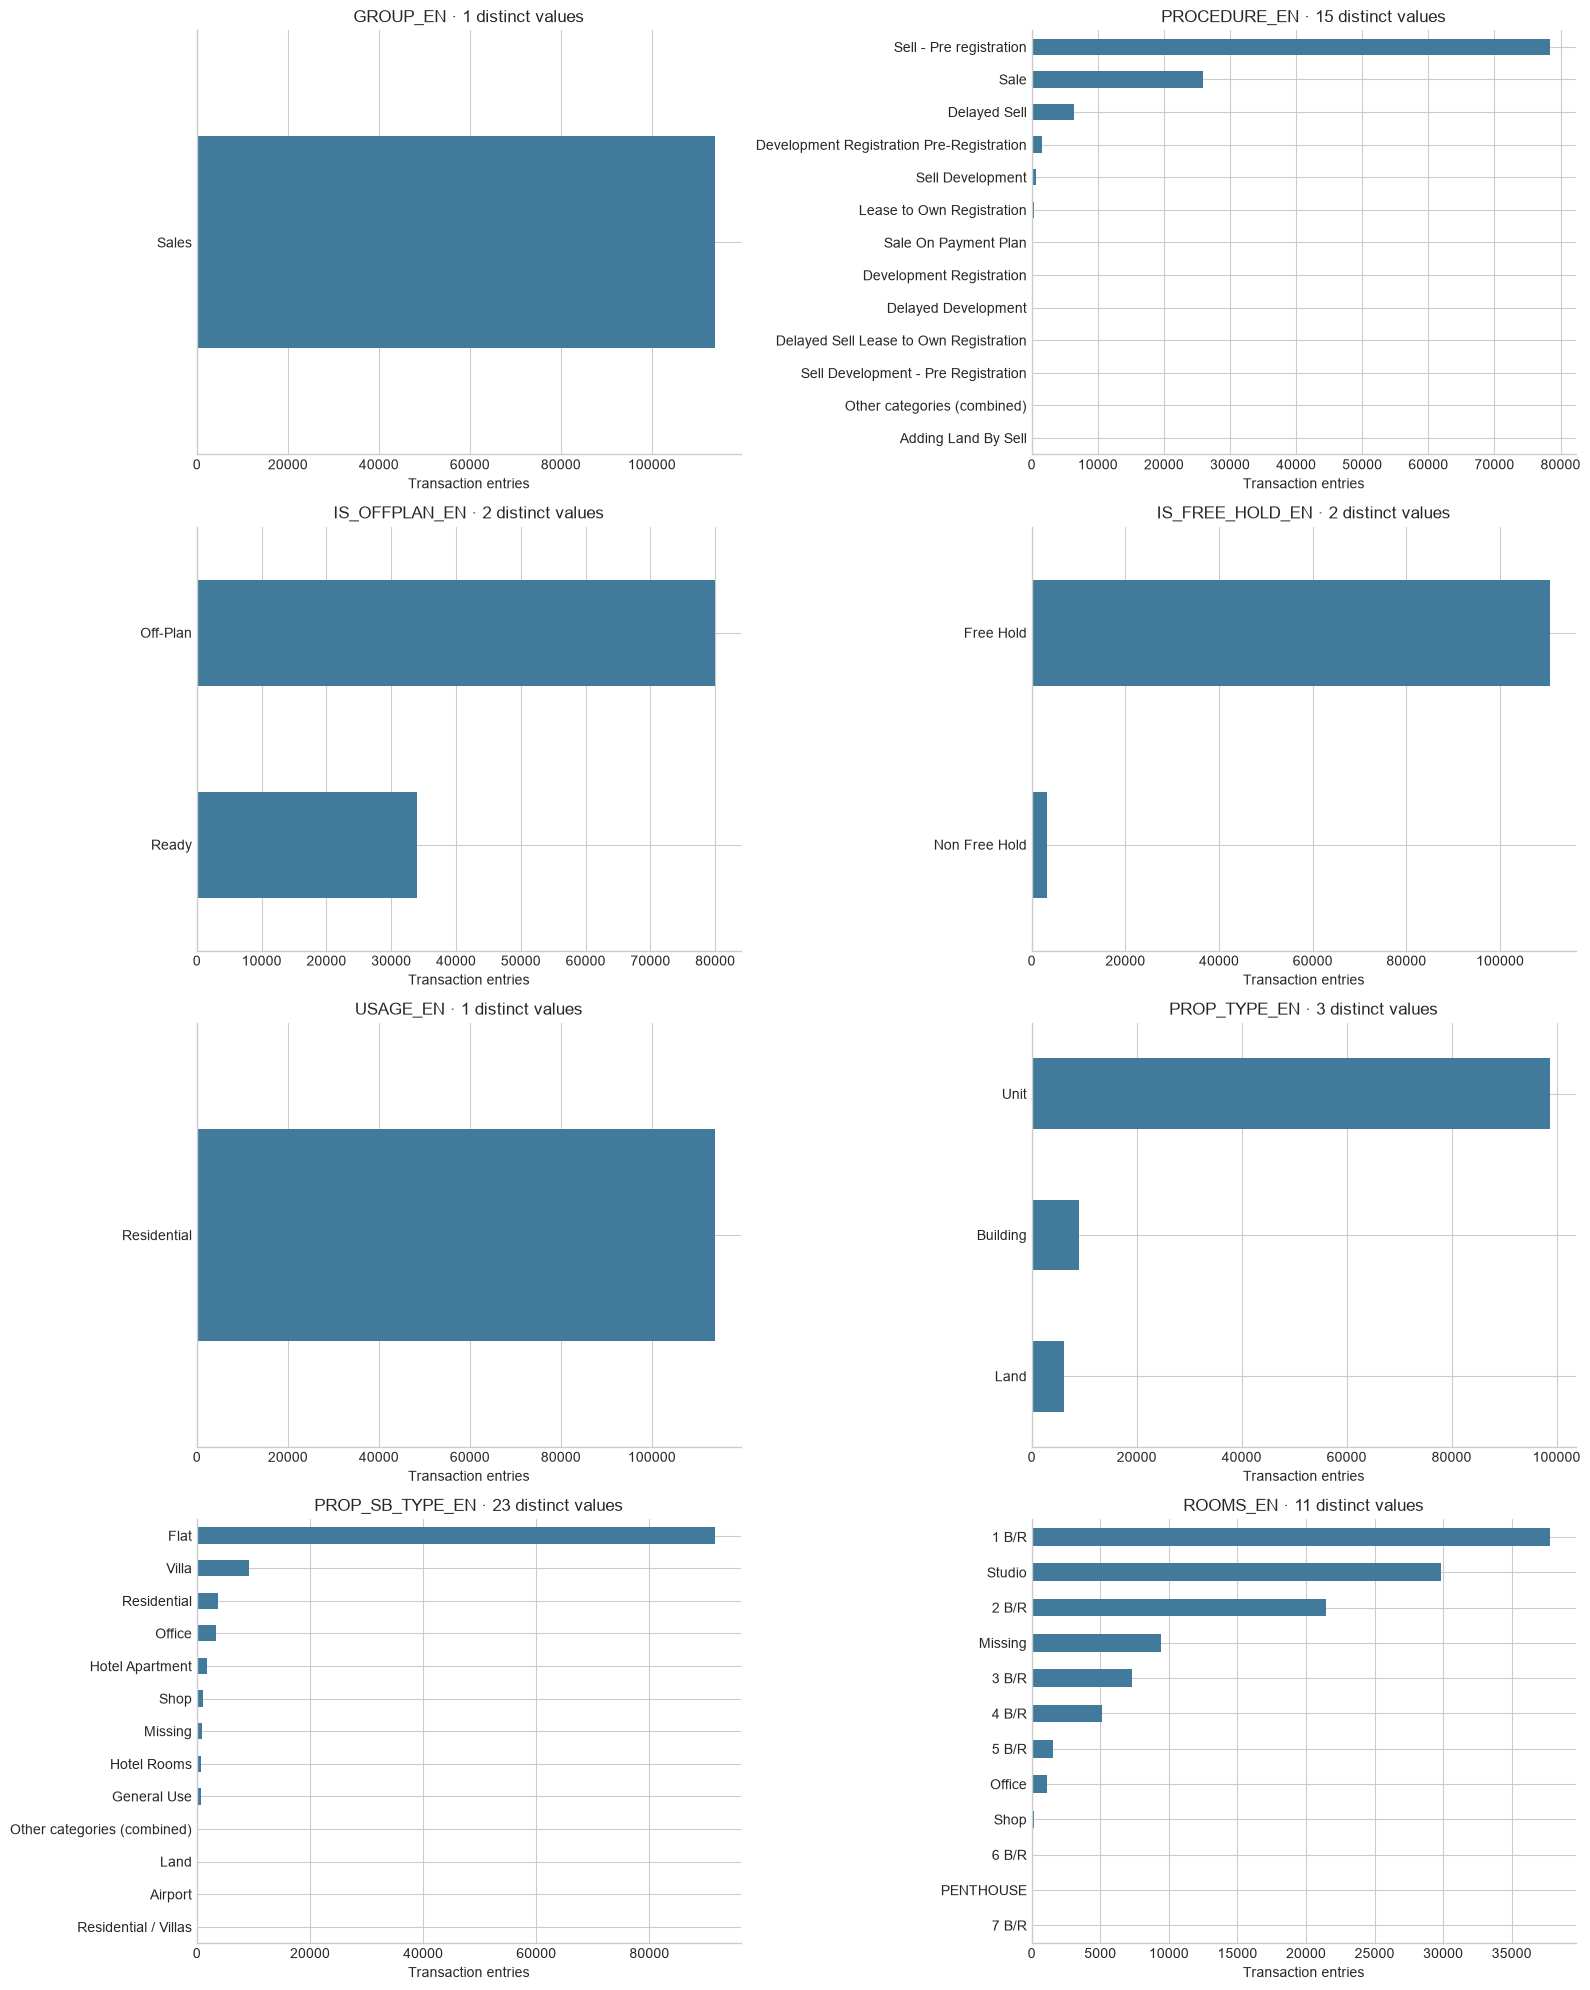

In [3]:
categorical_columns = ["GROUP_EN", "PROCEDURE_EN", "IS_OFFPLAN_EN", "IS_FREE_HOLD_EN",
                       "USAGE_EN", "PROP_TYPE_EN", "PROP_SB_TYPE_EN", "ROOMS_EN"]
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for column, ax in zip(categorical_columns, axes.flat):
    counts = df[column].fillna("Missing").value_counts()
    shown = counts.head(12).copy()
    if len(counts) > 12:
        shown.loc["Other categories (combined)"] = counts.iloc[12:].sum()
    shown.sort_values().plot.barh(ax=ax, color="#427a9b")
    ax.set(title=f"{column} · {df[column].nunique()} distinct values", xlabel="Transaction entries", ylabel="")
plt.tight_layout()
plt.show()

## 5. Residential scope
We narrow the question to apartments and villas because homes, land, offices and shops have different price mechanisms and surface definitions. Mixing them can make one regression model less consistent and its predictions harder to interpret.

We reuse the project's five residential subtype values: `Flat`, `Villa`, `Residential / Villas`, `Residential Flats`, and `Residential / Attached Villas`, and require Residential usage. This is an **analytical subset**, not a procedure-cleaning decision. All procedures within that subset remain available for inspection. The original `df` stays intact.

In [4]:
from src.preprocessing import RESIDENTIAL_TYPES

residential_mask = (df["PROP_SB_TYPE_EN"].isin(RESIDENTIAL_TYPES)
                    & df["USAGE_EN"].eq("Residential"))
res = df.loc[residential_mask].copy()
print("Residential subtypes:", sorted(RESIDENTIAL_TYPES))
print(f"Residential subset: {len(res):,} / {len(df):,} rows ({len(res) / len(df):.1%})")
display(res["PROP_SB_TYPE_EN"].value_counts().rename("rows").to_frame())

Residential subtypes: ['Flat', 'Residential / Attached Villas', 'Residential / Villas', 'Residential Flats', 'Villa']
Residential subset: 101,001 / 113,866 rows (88.7%)


,rows
PROP_SB_TYPE_EN,
Flat,91584
Villa,9141
Residential / Villas,142
Residential Flats,87
Residential / Attached Villas,47


## 6. Target analysis · TRANS_VALUE
The **mean** averages every price and is sensitive to very expensive sales. The **median** is the middle price, so it often better describes a typical transaction in a skewed market.

**Quartiles** divide ordered values into four parts: Q1 is the 25th percentile, Q2 the median, and Q3 the 75th percentile. **Quantiles** generalize this idea: the 99th percentile is the value below which approximately 99% of observations fall.

A **right-skewed distribution** has a long upper tail. Compare the full-range histogram with logarithmically spaced bins, which make multiplicative price differences visible while retaining AED units. Nonpositive or nonfinite values cannot appear on log axes; we count them explicitly and omit them only from that plot.

,TRANS_VALUE (AED)
count,"101,001.00"
mean,"2,084,527.84"
std,"4,229,609.08"
min,163.35
25%,"780,999.00"
50%,"1,310,000.00"
75%,"2,370,000.00"
max,"422,000,000.00"


Mean: AED 2,084,528 | Median: AED 1,310,000


,Price (AED)
0.01,"330,000.00"
0.25,"780,999.00"
0.50,"1,310,000.00"
0.75,"2,370,000.00"
0.90,"3,820,900.00"
0.95,"5,041,000.00"
0.99,"13,011,533.00"
1.00,"50,670,521.00"


Excluded from log-price plot only: 0 rows


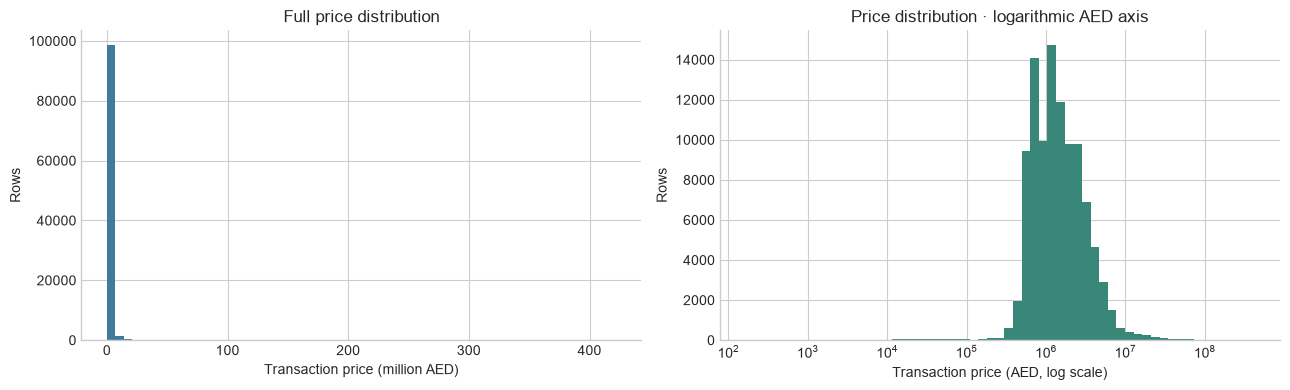

In [5]:
price = pd.to_numeric(res["TRANS_VALUE"], errors="coerce")
display(price.describe().rename("TRANS_VALUE (AED)").to_frame())
print(f"Mean: AED {price.mean():,.0f} | Median: AED {price.median():,.0f}")
display(price.quantile([.01, .25, .5, .75, .9, .95, .99, .999]).rename("Price (AED)").to_frame())
positive_price = price.loc[np.isfinite(price) & price.gt(0)]
print(f"Excluded from log-price plot only: {len(price) - len(positive_price):,} rows")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
price.loc[np.isfinite(price)].div(1_000_000).hist(bins=60, ax=axes[0], color="#427a9b")
axes[0].set(title="Full price distribution", xlabel="Transaction price (million AED)", ylabel="Rows")
axes[1].hist(positive_price, bins=np.geomspace(positive_price.min(), positive_price.max(), 60), color="#398779")
axes[1].set_xscale("log")
axes[1].set(title="Price distribution · logarithmic AED axis", xlabel="Transaction price (AED, log scale)", ylabel="Rows")
plt.tight_layout()
plt.show()

## 7. Surface analysis · ACTUAL_AREA
Surface is measured in square metres and is a plausible price driver: larger homes generally cost more, but location and property type can change that relationship. Check its range and tail before assuming every recorded area is comparable.

The scatterplot uses a fixed random sample for readability and log axes for positive values. Correlation summarizes association, not causation; an expensive small-unit record could also indicate a transaction-scope mismatch.

,Surface (m²)
count,"101,001.00"
mean,96.07
std,101.62
min,21.15
25%,44.09
50%,74.48
75%,114.94
max,"5,395.97"


,Surface (m²)
0.01,30.84
0.25,44.09
0.50,74.48
0.75,114.94
0.95,222.56
0.99,419.17
1.00,"1,108.48"


Nonpositive, missing or nonfinite surfaces: 0


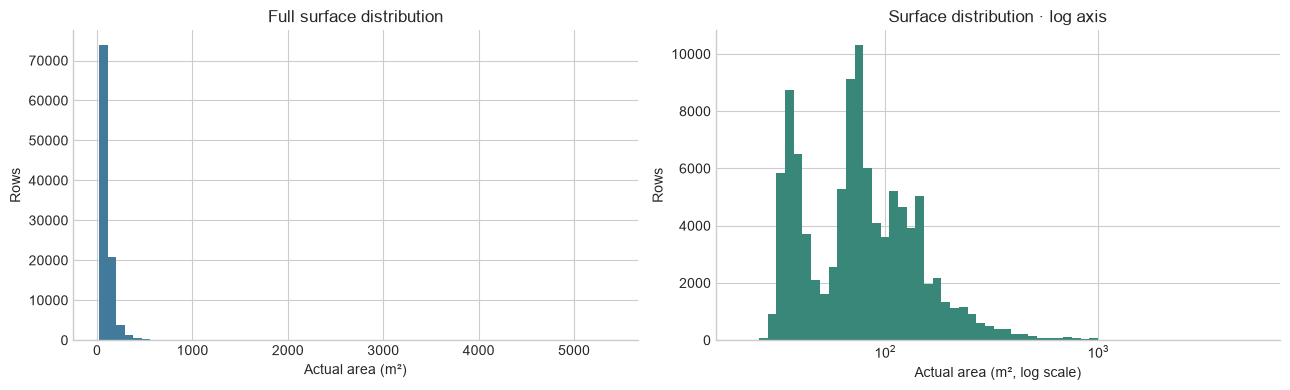

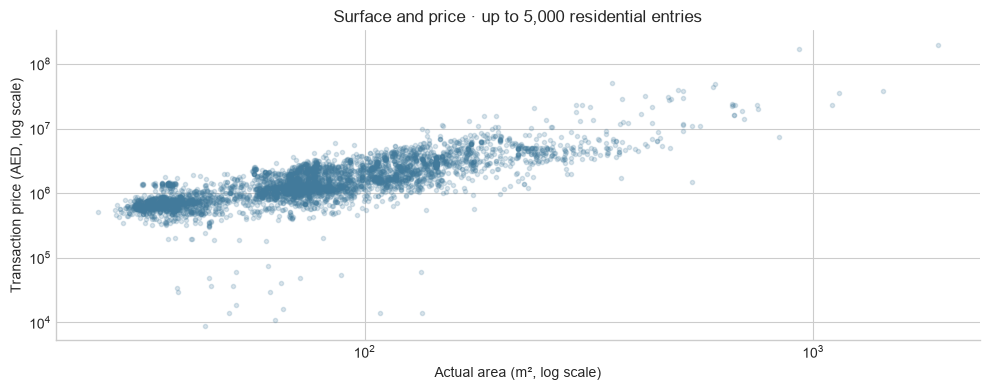

,ACTUAL_AREA,TRANS_VALUE
Spearman rank correlation,,
ACTUAL_AREA,1.00,0.83
TRANS_VALUE,0.83,1.00


In [6]:
surface = pd.to_numeric(res["ACTUAL_AREA"], errors="coerce")
display(surface.describe().rename("Surface (m²)").to_frame())
display(surface.quantile([.01, .25, .5, .75, .95, .99, .999]).rename("Surface (m²)").to_frame())
positive_surface = surface.loc[np.isfinite(surface) & surface.gt(0)]
print(f"Nonpositive, missing or nonfinite surfaces: {len(surface) - len(positive_surface):,}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
surface.loc[np.isfinite(surface)].hist(bins=60, ax=axes[0], color="#427a9b")
axes[0].set(title="Full surface distribution", xlabel="Actual area (m²)", ylabel="Rows")
axes[1].hist(positive_surface, bins=np.geomspace(positive_surface.min(), positive_surface.max(), 60), color="#398779")
axes[1].set_xscale("log")
axes[1].set(title="Surface distribution · log axis", xlabel="Actual area (m², log scale)", ylabel="Rows")
plt.tight_layout()
plt.show()

valid_pair = (np.isfinite(surface) & surface.gt(0) & np.isfinite(price) & price.gt(0))
scatter = res.loc[valid_pair].sample(min(5000, int(valid_pair.sum())), random_state=42)
fig, ax = plt.subplots()
ax.scatter(scatter["ACTUAL_AREA"], scatter["TRANS_VALUE"], s=9, alpha=.2, color="#427a9b")
ax.set(xscale="log", yscale="log", xlabel="Actual area (m², log scale)",
       ylabel="Transaction price (AED, log scale)", title="Surface and price · up to 5,000 residential entries")
plt.tight_layout()
plt.show()
display(res[["ACTUAL_AREA", "TRANS_VALUE"]].corr(method="spearman").rename_axis("Spearman rank correlation"))

## 8. Outliers · flags, not deletion rules
An **outlier** is an observation far from most others. **Outlier ≠ bad data**: a luxury villa can be both statistically extreme and correctly recorded.

The **interquartile range** covers the middle half of the data:

- Q1 = 25th percentile; Q3 = 75th percentile.
- IQR = Q3 − Q1.
- Lower bound = Q1 − 1.5 × IQR.
- Upper bound = Q3 + 1.5 × IQR.

Values outside these conventional bounds are investigation flags. A negative lower bound is a statistical calculation, not a claim that negative prices or areas are valid. We count flags and keep every residential record; business evidence must justify any later exclusion.

In [7]:
iqr_rows = []
for column in ["TRANS_VALUE", "ACTUAL_AREA"]:
    values = res[column]
    q1 = values.quantile(.25)
    q3 = values.quantile(.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = values.lt(lower) | values.gt(upper)
    iqr_rows.append({"variable": column, "Q1": q1, "Q3": q3, "IQR": iqr,
                     "lower_bound": lower, "upper_bound": upper,
                     "flagged_rows": flagged.sum(), "flagged_pct": flagged.mean() * 100})
with pd.option_context("display.max_columns", 8):
    display(pd.DataFrame(iqr_rows).set_index("variable"))
print(f"Residential rows retained for analysis: {len(res):,}")

,Q1,Q3,IQR,lower_bound,upper_bound,flagged_rows,flagged_pct
variable,,,,,,,
TRANS_VALUE,"780,999.00","2,370,000.00","1,589,001.00","-1,602,502.50","4,753,501.50",6217,6.16
ACTUAL_AREA,44.09,114.94,70.85,-62.18,221.21,5149,5.10


Residential rows retained for analysis: 101,001


## 9. Diagnostic feature engineering
**Feature engineering** constructs useful variables from existing fields. Here the new variables are **for analysis only**:

- `PRICE_PER_SQM = TRANS_VALUE / ACTUAL_AREA` compares prices relative to surface.
- `AREA_RATIO = PROCEDURE_AREA / ACTUAL_AREA` compares two recorded area definitions.

**PRICE_PER_SQM must NOT be a model feature. It contains TRANS_VALUE and would cause target leakage.** Target leakage gives the model information derived from the answer or unavailable when making a real prediction, creating misleadingly good evaluation results.

`AREA_RATIO` is also kept diagnostic-only in this project. Both ratios require a finite, positive denominator. Undefined ratios stay missing; we do not replace them with zero or alter the source fields.

In [8]:
denominator = res["ACTUAL_AREA"].where(np.isfinite(res["ACTUAL_AREA"]) & res["ACTUAL_AREA"].gt(0))
res["PRICE_PER_SQM"] = (res["TRANS_VALUE"] / denominator).replace([np.inf, -np.inf], np.nan)
res["AREA_RATIO"] = (res["PROCEDURE_AREA"] / denominator).replace([np.inf, -np.inf], np.nan)
display(res[["PRICE_PER_SQM", "AREA_RATIO"]].quantile([0, .25, .5, .75, .95, .99, 1]))
print("Undefined diagnostic values:")
display(res[["PRICE_PER_SQM", "AREA_RATIO"]].isna().sum().rename("rows").to_frame())

,PRICE_PER_SQM,AREA_RATIO
0.00,1.91,0.01
0.25,"14,975.66",1.00
0.50,"18,497.20",1.00
0.75,"23,480.81",1.00
0.95,"36,625.31",1.00
0.99,"48,256.19",1.00
1.00,"2,207,992.93",101.98


Undefined diagnostic values:


,rows
PRICE_PER_SQM,0
AREA_RATIO,1


## 10. Suspicious transactions
An entry can be valid in the official database yet unsuitable for our prediction question. A development-level amount paired with an individual unit's area would not be a coherent training example for an individual home's price.

Inspect the highest price-per-square-metre entries, area ratios above 2, and development or lease-to-own procedures. These are **review queues**, not proof of errors or exclusion rules. For example, a 100-million-AED amount attached to 45.29 m² and procedure area 4,618.6 m² warrants a scope check, even if each field is correctly recorded. Luxury location alone may explain some high unit prices.

In [9]:
review_columns = ["PROCEDURE_EN", "ACTUAL_AREA", "PROCEDURE_AREA", "TRANS_VALUE", "PRICE_PER_SQM", "AREA_RATIO"]
with pd.option_context("display.max_columns", 6):
    print("Highest recorded price per square metre — residential subset")
    display(res.nlargest(6, "PRICE_PER_SQM")[review_columns])
    print("Procedure area more than twice actual area — largest ratios")
    display(res.loc[res["AREA_RATIO"].gt(2)].nlargest(6, "AREA_RATIO")[review_columns])
    unusual = res["PROCEDURE_EN"].str.contains("Development|Lease to Own", case=False, na=False)
    print(f"Development / lease-to-own entries: {unusual.sum():,}; examples ordered by area ratio")
    display(res.loc[unusual].nlargest(6, "AREA_RATIO")[review_columns])

Highest recorded price per square metre — residential subset


,PROCEDURE_EN,ACTUAL_AREA,PROCEDURE_AREA,TRANS_VALUE,PRICE_PER_SQM,AREA_RATIO
104774,Development Registration,45.29,"4,618.60","100,000,000.00","2,207,992.93",101.98
104807,Development Registration,117.94,"4,618.60","100,000,000.00","847,888.76",39.16
32502,Sell - Pre registration,222.91,222.91,"117,655,556.46","527,816.41",1.00
77690,Sell - Pre registration,76.36,76.36,"26,990,999.00","353,470.39",1.00
27172,Sell - Pre registration,931.01,931.01,"171,036,254.00","183,710.44",1.00
59914,Sell - Pre registration,931.01,931.01,"166,077,188.00","178,383.89",1.00


Procedure area more than twice actual area — largest ratios


,PROCEDURE_EN,ACTUAL_AREA,PROCEDURE_AREA,TRANS_VALUE,PRICE_PER_SQM,AREA_RATIO
104774,Development Registration,45.29,"4,618.60","100,000,000.00","2,207,992.93",101.98
104807,Development Registration,117.94,"4,618.60","100,000,000.00","847,888.76",39.16
76560,Sell - Pre registration,69.27,180.31,"2,231,508.00","32,214.64",2.60
42491,Sell - Pre registration,29.78,65.93,"578,000.00","19,409.00",2.21
65182,Sell - Pre registration,32.45,70.63,"1,015,000.00","31,278.89",2.18
77798,Sell - Pre registration,127.90,261.20,"1,694,298.14","13,247.05",2.04


Development / lease-to-own entries: 2,745; examples ordered by area ratio


,PROCEDURE_EN,ACTUAL_AREA,PROCEDURE_AREA,TRANS_VALUE,PRICE_PER_SQM,AREA_RATIO
104774,Development Registration,45.29,"4,618.60","100,000,000.00","2,207,992.93",101.98
104807,Development Registration,117.94,"4,618.60","100,000,000.00","847,888.76",39.16
111622,Sell Development,49.75,49.76,"555,000.00","11,155.78",1.00
78373,Lease to Own Registration Pre-Registration,338.98,338.98,"4,150,000.00","12,242.61",1.00
78374,Lease to Own Registration Pre-Registration,69.94,69.94,"735,000.00","10,509.01",1.00
78375,Lease to Own Registration Pre-Registration,83.11,83.11,"1,000,000.00","12,032.25",1.00


## 11. Procedure analysis
Group procedures to see whether scope mismatches are isolated or systematic. Counts show how much evidence supports each summary. A median ratio near 1 suggests that the two area fields agree for a typical row. The mean and maximum expose a tail that the median can hide. Agreement does not prove that price represents a whole individual property.

Sale, Sell - Pre registration, Delayed Sell and Sale On Payment Plan are candidate individual-sale procedures for domain review. Development labels deserve particular scrutiny, even when their median ratio is 1. Lease-to-own arrangements may represent a different economic transaction. We summarize all procedures without applying an allowlist here.

In [10]:
procedure_summary = res.groupby("PROCEDURE_EN", dropna=False).agg(
    rows=("TRANS_VALUE", "size"),
    ratio_available=("AREA_RATIO", "count"),
    area_ratio_median=("AREA_RATIO", "median"),
    area_ratio_mean=("AREA_RATIO", "mean"),
    area_ratio_max=("AREA_RATIO", "max"),
).sort_values("rows", ascending=False)
display(procedure_summary)
display(res[["ACTUAL_AREA", "PROCEDURE_AREA"]].corr().rename_axis("Pearson area correlation"))

,rows,ratio_available,area_ratio_median,area_ratio_mean,area_ratio_max
PROCEDURE_EN,,,,,
Sell - Pre registration,74099,74099,1.00,1.00,2.60
Sale,21042,21041,1.00,0.99,2.00
Delayed Sell,2881,2881,1.00,0.99,1.00
Development Registration Pre-Registration,1558,1558,1.00,1.00,1.00
Sell Development,539,539,1.00,0.98,1.00
Lease to Own Registration,344,344,1.00,1.00,1.00
Sale On Payment Plan,234,234,1.00,1.00,1.00
Development Registration,159,159,1.00,1.88,101.98
Delayed Development,75,75,1.00,1.00,1.00


,ACTUAL_AREA,PROCEDURE_AREA
Pearson area correlation,,
ACTUAL_AREA,1.00,0.97
PROCEDURE_AREA,0.97,1.00


## 12. Location and project analysis
Location can explain price differences between similarly sized homes. `AREA_EN` and especially `PROJECT_EN` are high-cardinality categories: project identity may capture building quality or location, but one-hot encoding every rare project creates many sparse columns and can encourage overfitting.

Show only the 12 most frequent areas and projects. For area median comparisons, require **at least 100 observed residential entries** as a transparent display rule, not a statistical guarantee. Median prices also reflect local mixes of surface, bedrooms and property types, so this is not a ranking of like-for-like location premiums. All summaries still include unreviewed procedures.

,unique_nonmissing,missing_pct
AREA_EN,159,0.00
PROJECT_EN,2483,5.62


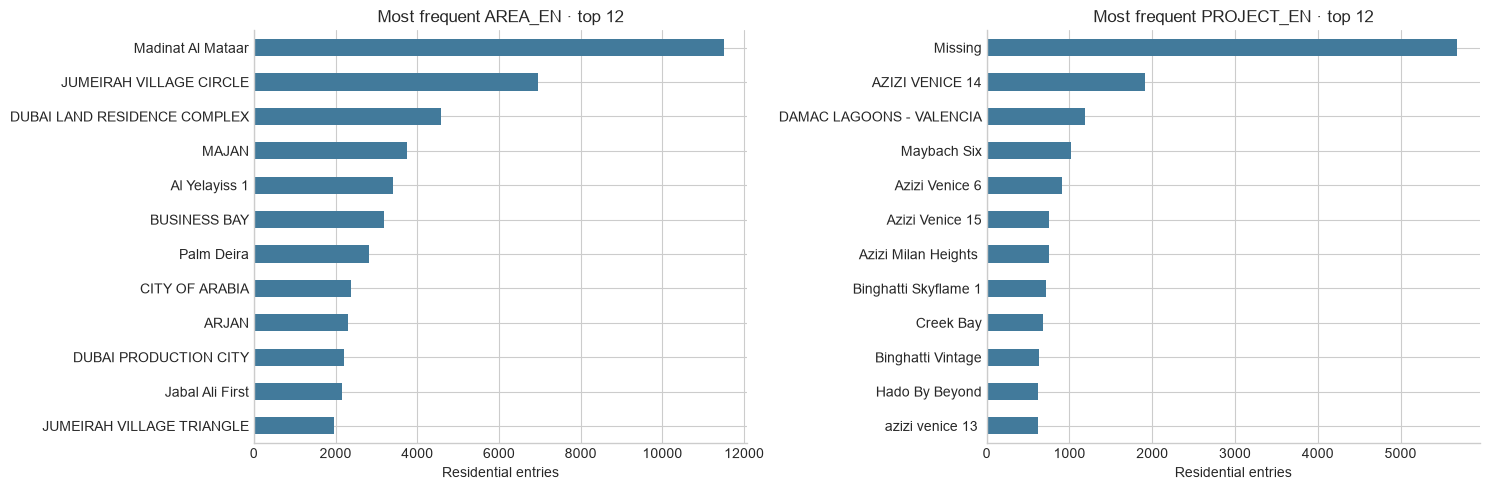

Areas with at least 100 entries: 93


,rows,median_price_AED,median_price_per_sqm
AREA_EN,,,
Marsa Dubai,326,"7,870,000.00","47,988.42"
Saih Shuaib 1,386,"6,575,000.00","29,196.01"
Nad Al Shiba First,292,"6,075,500.00","24,084.86"
PALM JUMEIRAH,680,"5,900,000.00","37,818.28"
DUBAI WATER CANAL,148,"4,887,500.00","32,937.53"
CITY WALK,161,"4,399,958.90","28,783.70"
Palm Jabal Ali,315,"4,378,000.00","37,713.79"
EMIRATE LIVING,245,"4,350,000.00","17,926.94"
DUBAI HARBOUR,262,"4,000,000.00","38,156.11"


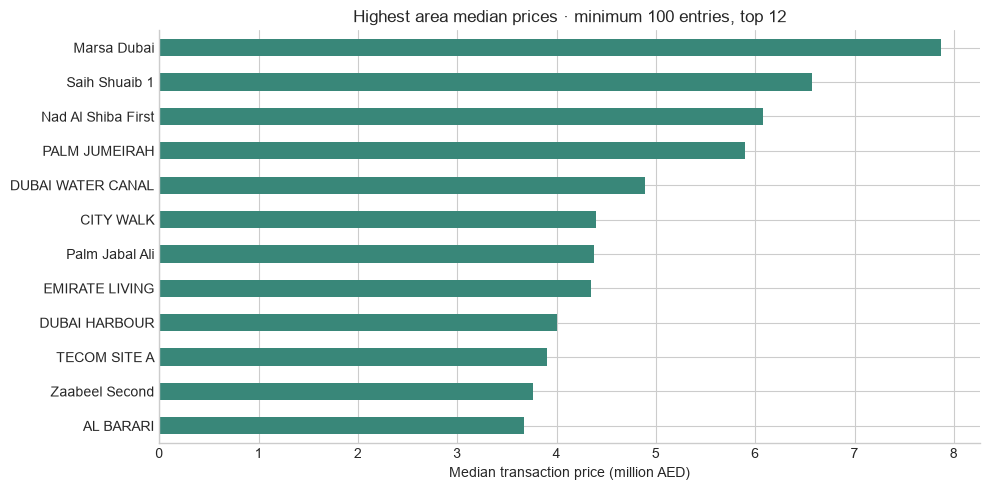

In [11]:
display(pd.DataFrame({"unique_nonmissing": res[["AREA_EN", "PROJECT_EN"]].nunique(),
                      "missing_pct": res[["AREA_EN", "PROJECT_EN"]].isna().mean() * 100}))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for column, ax in zip(["AREA_EN", "PROJECT_EN"], axes):
    res[column].fillna("Missing").value_counts().head(12).sort_values().plot.barh(ax=ax, color="#427a9b")
    ax.set(title=f"Most frequent {column} · top 12", xlabel="Residential entries", ylabel="")
plt.tight_layout()
plt.show()

MIN_AREA_COUNT = 100
area_summary = res.groupby("AREA_EN").agg(rows=("TRANS_VALUE", "size"),
                                          median_price_AED=("TRANS_VALUE", "median"),
                                          median_price_per_sqm=("PRICE_PER_SQM", "median"))
frequent_areas = area_summary.loc[area_summary["rows"].ge(MIN_AREA_COUNT)]
print(f"Areas with at least {MIN_AREA_COUNT} entries: {len(frequent_areas)}")
area_top = frequent_areas.sort_values("median_price_AED", ascending=False).head(12)
display(area_top)
ax = area_top["median_price_AED"].sort_values().div(1_000_000).plot.barh(color="#398779", figsize=(10, 5))
ax.set(title="Highest area median prices · minimum 100 entries, top 12",
       xlabel="Median transaction price (million AED)", ylabel="")
plt.tight_layout()
plt.show()

## 13. Price relationships
The surface scatterplot in section 7 shows the numeric relationship. Next compare distributions across room counts, Flat versus Villa, completion status and tenure. A box shows the middle 50% and median; whiskers extend to the conventional IQR bounds. Outlier dots are hidden **only for visual readability**; all positive prices contribute to the summaries and box statistics. Log axes show relative price differences.

Parse Studio as zero bedrooms and labels such as `2 B/R` as two. Other labels (for example PENTHOUSE) cannot be translated safely and remain unparsed. The Flat/Villa comparison uses those exact labels, leaving the three broader Residential subtypes separate rather than assuming equivalent meanings.

Group differences are **associations**, not causal effects: off-plan and ready properties may differ in location, size and quality. Counts reveal unequal sample sizes; a median based on a handful of entries is unstable.

Unparsed/missing bedroom labels: 406


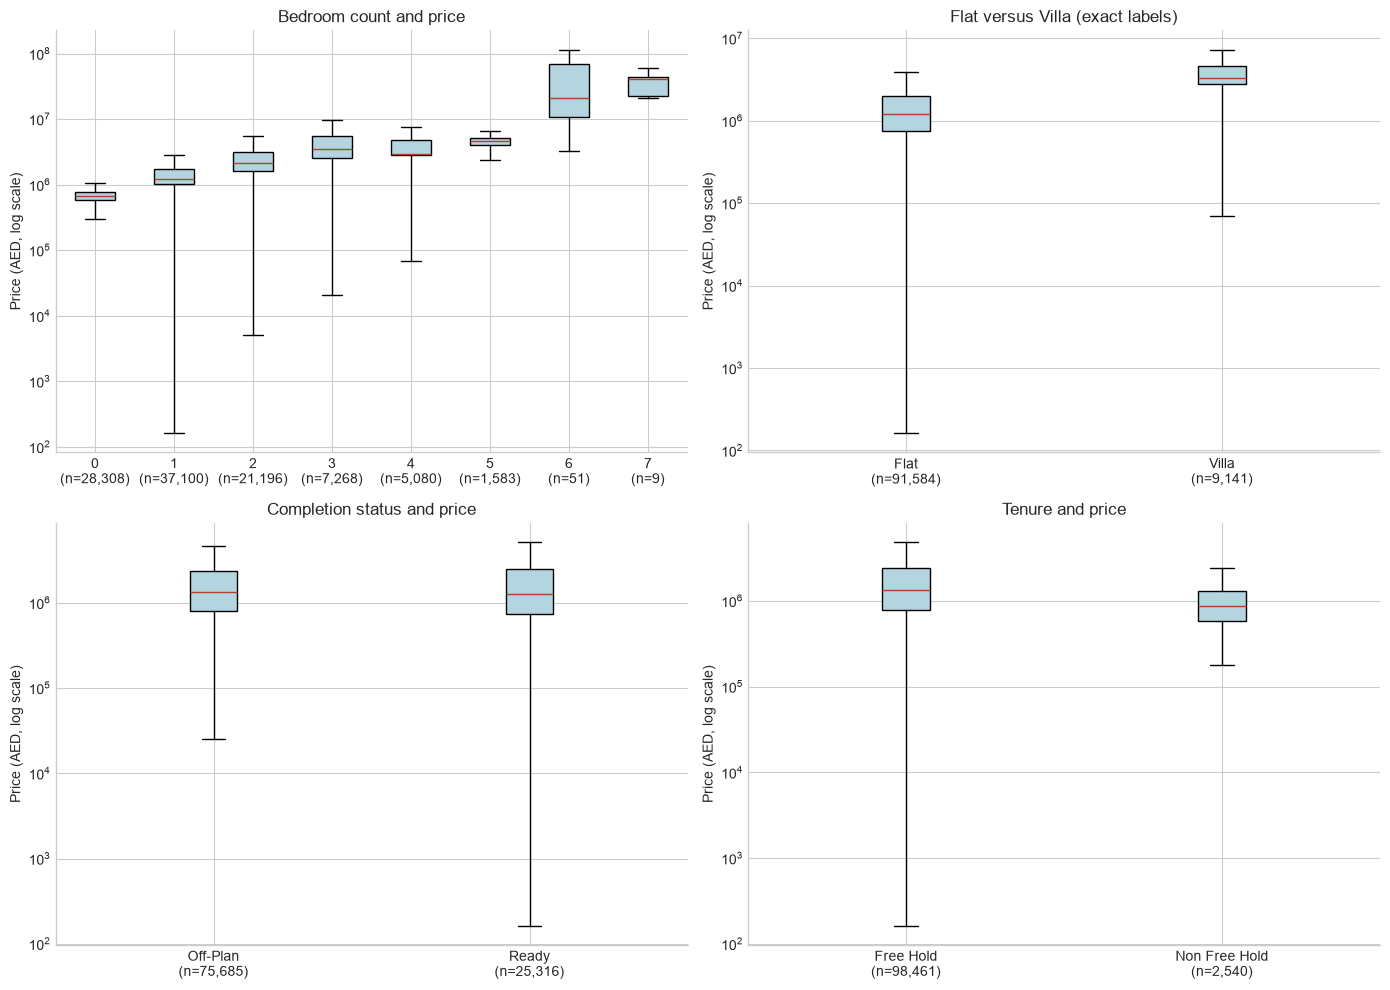

BEDROOMS_DIAGNOSTIC


,rows,median_AED
BEDROOMS_DIAGNOSTIC,,
0,28308,"673,000.00"
1,37100,"1,242,814.91"
2,21196,"2,175,080.00"
3,7268,"3,521,944.00"
4,5080,"2,982,000.00"
5,1583,"4,609,920.00"
6,51,"21,100,000.00"
7,9,"41,134,000.00"
<NA>,406,"17,667,000.00"


PROP_SB_TYPE_EN


,rows,median_AED
PROP_SB_TYPE_EN,,
Flat,91584,"1,220,000.00"
Residential / Attached Villas,47,"1,499,000.00"
Residential / Villas,142,"20,460,000.00"
Residential Flats,87,"21,000,000.00"
Villa,9141,"3,300,000.00"


IS_OFFPLAN_EN


,rows,median_AED
IS_OFFPLAN_EN,,
Off-Plan,75685,"1,324,888.00"
Ready,25316,"1,260,000.00"


IS_FREE_HOLD_EN


,rows,median_AED
IS_FREE_HOLD_EN,,
Free Hold,98461,"1,327,999.00"
Non Free Hold,2540,"865,600.00"


In [12]:
room_text = res["ROOMS_EN"].astype("string")
res["BEDROOMS_DIAGNOSTIC"] = pd.to_numeric(room_text.str.extract(r"^(\d+)\s*B/R$", expand=False), errors="coerce")
res.loc[room_text.eq("Studio").fillna(False), "BEDROOMS_DIAGNOSTIC"] = 0
print(f"Unparsed/missing bedroom labels: {res['BEDROOMS_DIAGNOSTIC'].isna().sum():,}")

# Build four compact comparisons without changing the analytical population.
comparisons = [
    ("BEDROOMS_DIAGNOSTIC", sorted(res["BEDROOMS_DIAGNOSTIC"].dropna().unique()), "Bedroom count and price"),
    ("PROP_SB_TYPE_EN", ["Flat", "Villa"], "Flat versus Villa (exact labels)"),
    ("IS_OFFPLAN_EN", ["Off-Plan", "Ready"], "Completion status and price"),
    ("IS_FREE_HOLD_EN", ["Free Hold", "Non Free Hold"], "Tenure and price"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for (column, categories, title), ax in zip(comparisons, axes.flat):
    groups = []
    labels = []
    for category in categories:
        values = res.loc[res[column].eq(category), "TRANS_VALUE"]
        values = values.loc[np.isfinite(values) & values.gt(0)]
        if len(values):
            groups.append(values)
            label = f"{category:g}" if isinstance(category, (float, np.floating)) else str(category)
            labels.append(f"{label}\n(n={len(values):,})")
    ax.boxplot(groups, showfliers=False, patch_artist=True,
               boxprops={"facecolor": "#b4d4df"}, medianprops={"color": "#aa4528"})
    ax.set_xticks(range(1, len(labels) + 1), labels)
    ax.set(yscale="log", title=title, ylabel="Price (AED, log scale)")
plt.tight_layout()
plt.show()

for column in ["BEDROOMS_DIAGNOSTIC", "PROP_SB_TYPE_EN", "IS_OFFPLAN_EN", "IS_FREE_HOLD_EN"]:
    print(column)
    display(res.groupby(column, dropna=False)["TRANS_VALUE"].agg(rows="size", median_AED="median"))

## 14. Key EDA findings and preprocessing questions

- **Population:** the supplied export has 113,866 entries and 22 columns; the residential apartment/villa subset contains 101,001 entries. Flat transactions dominate. The January–September 2026 window is short, so it cannot establish long-term market behavior.
- **Price and surface:** inspect the mean/median gap and long upper tails. Surface, location, room count, property subtype, completion status and tenure are plausible inputs. Group price differences also reflect differences in property mix.
- **Data quality:** missing project/location details and room labels require explicit treatment. MASTER_PROJECT_EN is almost entirely missing. Exact duplicates and repeated transaction IDs need separate review. Missingness should not automatically become zero.
- **Limited-value inputs:** GROUP_EN, USAGE_EN and buyer/seller counts have no variation in this supplied export. TRANSACTION_NUMBER is an identifier. PARKING can contain bay labels such as B-99 rather than counts, so it should not be naively converted into parking capacity.
- **Suspicious scope:** Development Registration includes procedure areas about 102 times actual surface. Very high unit prices, extreme area ratios and unusual procedures need business review; a valid official record can be outside the individual-home prediction scope. Ratio agreement alone does not validate a sale.
- **Encoding risks:** PROJECT_EN has many categories, including rare or missing projects. Area/project encoding, imputation and any learned category grouping must be fitted using training data only.
- **Leakage and evaluation:** PRICE_PER_SQM contains the target and must never be used for training. Diagnostic ratios remain outside the model input schema. Later transactions should evaluate earlier training; repeated homes may still cross splits because transaction IDs are not stable property IDs.
- **Preprocessing handoff:** validate dates, prices and surfaces; review duplicate IDs and procedure eligibility; investigate mismatched areas; handle missing categories; choose useful date features; exclude inappropriate identifiers/constants and ambiguous fields. Preserve legitimate luxury sales rather than deleting everything outside IQR fences. These questions belong in the cleaning stage; **this notebook makes no destructive filtering decisions**.

The existing preprocessing and trained model are unchanged. Findings informed by the full snapshot are exploratory; future rule or model changes require evaluation on an independent later period.

## 15. Machine Learning concepts learned

| Concept | Meaning in this project |
|---|---|
| Supervised learning | Learn from historical property information paired with known transaction prices. |
| Regression | Predict a continuous numeric amount, here AED. |
| Feature | An input available when making a prediction, such as actual surface. |
| Target | The outcome to predict: TRANS_VALUE. |
| EDA | Inspect distributions, relationships and data quality before modeling. |
| Missing values | Information that is absent; it is not necessarily zero. |
| Categorical variables | Group labels such as area, property type or completion status. |
| Feature engineering | Derive useful quantities from raw fields; diagnostic quantities are not automatically model inputs. |
| Outliers | Unusual observations that may be errors, different transaction scopes or valid luxury properties. |
| Quartiles | The 25th, 50th and 75th percentiles of an ordered distribution. |
| IQR | Q3 − Q1, the spread of the middle half of observations. |
| Target leakage | Giving the model information derived from the answer or unavailable at prediction time. |
| High cardinality | Many distinct categories, making encoding and generalization more difficult. |

The key habit is to ask **what a record means and why an analysis matters** before deciding how a model should use it.